# Convergence of the partial trace $\mathrm{tr}_p(S^{(q)})$

Diagnostic for **Theorem 3.4**. On a *fixed* covariance matrix we apply the pairwise
(Jacobi-style) eigen-rotations one at a time and track the top-$p$ partial trace

$$\mathrm{tr}_p\big(S^{(q)}\big)=\sum_{i=0}^{p-1} S^{(q)}_{ii}$$

against the theoretical ceiling from (3.1), the sum of the top-$p$ eigenvalues of the
original covariance. The expected picture: a quick rise that flattens as it saturates the
ceiling (geometric growth, then saturation once the pivot assumption stops holding).

Run this from the same directory as the main benchmark (so `import pairwise_eig` resolves).

> **Note.** This notebook overlays two curves: the rotation as currently implemented in
> `pairwise_eig.py`, and a corrected orientation. With the current orientation the partial
> trace is *not* strictly monotone and plateaus below the ceiling; see the final cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pairwise_eig as pe

np.set_printoptions(suppress=True, precision=4, linewidth=200)

## 1. A fixed covariance matrix

Synthetic, reproducible, with a controllable decaying spectrum so the ceiling is clean and
the top-$p$ block captures most of the variance. Swap in a real covariance by uncommenting
the data-driven block.

In [2]:
def build_synthetic_covariance(n=64, decay=0.85, scale=100.0, seed=0):
    """Random orthonormal eigenbasis with geometrically decaying eigenvalues."""
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    eigs = scale * decay ** np.arange(n)
    S = (Q * eigs) @ Q.T
    return 0.5 * (S + S.T)          # enforce exact symmetry


def topp_ceiling(S, p):
    """Sum of the p largest eigenvalues = theoretical max partial trace, eq. (3.1)."""
    return np.sort(np.linalg.eigvalsh(S))[::-1][:p].sum()


N, P = 64, 15
S0 = build_synthetic_covariance(n=N, decay=0.85, scale=100.0, seed=0)

# --- Alternative: build S0 from a real data chunk --------------------------
# import os
# DATA_DIR = "datasets/yearprediction"
# chunk = np.load(os.path.join(DATA_DIR, "X_0001.npy")).astype(np.float64)  # (m, d)
# Xc = chunk - chunk.mean(0, keepdims=True)
# S0 = (Xc.T @ Xc) / Xc.shape[0]            # (d, d) covariance
# N, P = S0.shape[0], 15
# ---------------------------------------------------------------------------

CEILING = topp_ceiling(S0, P)
print(f"n = {N}, p = {P}")
print(f"initial tr_p (top-left block) : {np.trace(S0[:P, :P]):.4f}")
print(f"ceiling (sum of top-{P} eigs)  : {CEILING:.4f}")
print(f"total trace                   : {np.trace(S0):.4f}")

n = 64, p = 15
initial tr_p (top-left block) : 124.4958
ceiling (sum of top-15 eigs)  : 608.4305
total trace                   : 666.6464


## 2. Tracking the partial trace across iterations

We drive the real `pairwise_eig.fit_safe` one rotation at a time (`n_iter=1`) and read
$\mathrm{tr}_p$ after each step. `fit_safe` is plain Python orchestration over the
`@njit` kernels, so we can swap in a corrected `jacobi_2x2_rotation` by temporarily
rebinding the module attribute.

In [3]:
def jacobi_2x2_rotation_fixed(sii, sjj, sij):
    """Corrected orientation: guarantees the LARGER block eigenvalue lands at (0,0)=i.

    Same closed form as pairwise_eig.jacobi_2x2_rotation, but the orientation test
    compares the actual post-rotation diagonal entries instead of a sign-flipped proxy.
    """
    G = np.zeros((2, 2), dtype=np.float64)
    if sij == 0.0:
        if sjj > sii:
            G[0, 1] = -1.0; G[1, 0] = 1.0
        else:
            G[0, 0] = 1.0; G[1, 1] = 1.0
        return G

    diff = sii - sjj
    if diff == 0.0:
        t = 1.0 if sij > 0.0 else -1.0
        c = 1.0 / np.sqrt(2.0); s = t * c
    else:
        tau = diff / (2.0 * sij)
        if abs(tau) > 1e8:
            t = 0.5 / tau
        elif tau >= 0.0:
            t = 1.0 / (tau + np.sqrt(1.0 + tau * tau))
        else:
            t = 1.0 / (tau - np.sqrt(1.0 + tau * tau))
        c = 1.0 / np.sqrt(1.0 + t * t); s = t * c

    # actual resulting diagonals for G = [[c,-s],[s,c]]
    new_ii = c * c * sii + 2.0 * c * s * sij + s * s * sjj
    new_jj = s * s * sii - 2.0 * c * s * sij + c * c * sjj
    if new_ii >= new_jj:
        G[0, 0] = c;  G[0, 1] = -s; G[1, 0] = s;  G[1, 1] = c
    else:                                  # swap columns -> larger eigenvalue to (0,0)
        G[0, 0] = -s; G[0, 1] = c;  G[1, 0] = c;  G[1, 1] = s
    return G


def track_partial_trace(S0, p, n_iter, use_fixed_rotation=False):
    """Apply n_iter single Jacobi rotations to a fixed S0, recording tr_p after each."""
    n = S0.shape[0]
    S = np.array(S0, dtype=np.float64, copy=True)
    U = np.eye(n, dtype=np.float64)

    scores = np.empty((p, n), dtype=np.float64);                scores.fill(pe.NEG_INF32)
    rtv    = np.empty((p, pe.TOP_K_SCORES), dtype=np.float64);   rtv.fill(pe.NEG_INF32)
    rti    = np.empty((p, pe.TOP_K_SCORES), dtype=np.int64);     rti.fill(-1)

    pe.set_num_threads(pe.NUMBA_THREADS)
    pe._init_global_buf(n, n, np.float64)

    saved = pe.jacobi_2x2_rotation
    if use_fixed_rotation:
        pe.jacobi_2x2_rotation = jacobi_2x2_rotation_fixed
    try:
        traces = np.empty(n_iter + 1, dtype=np.float64)
        traces[0] = np.trace(S[:p, :p])
        for q in range(1, n_iter + 1):
            U, S = pe.fit_safe(S, p, 1, U, scores, rtv, rti, pe.TEMP_COL)
            traces[q] = np.trace(S[:p, :p])
    finally:
        pe.jacobi_2x2_rotation = saved      # always restore
    return traces


N_ITER = 2000
tr_current = track_partial_trace(S0, P, N_ITER, use_fixed_rotation=False)
tr_fixed   = track_partial_trace(S0, P, N_ITER, use_fixed_rotation=True)

## 3. Convergence plot

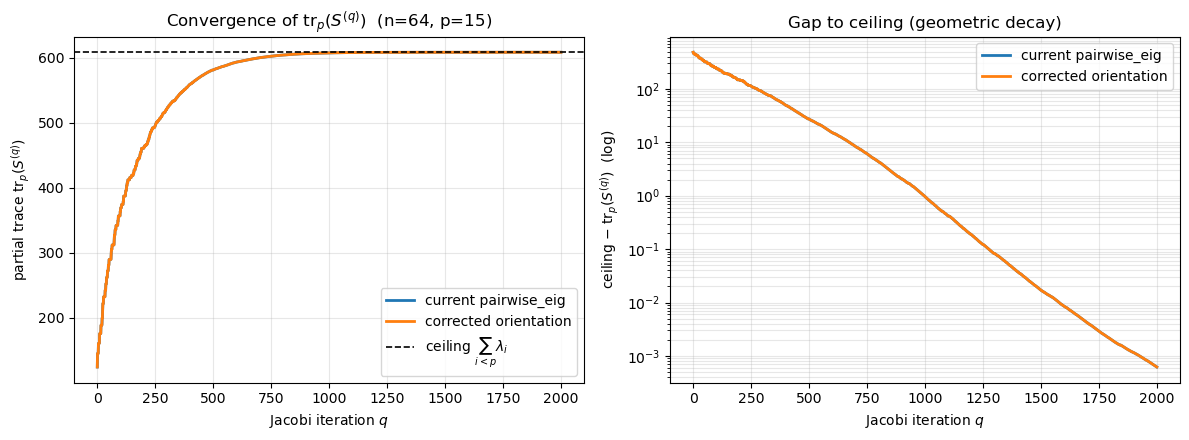

In [9]:
def plot_convergence(curves, ceiling, n_iter, title=None):
    """curves: dict {label: trace_array}. Left: tr_p vs iter. Right: gap on log scale."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    it = np.arange(n_iter + 1)

    for label, tr in curves.items():
        ax1.plot(it, tr, lw=2, label=label)
    ax1.axhline(ceiling, color="k", ls="--", lw=1.2, label="ceiling $\\sum_{i<p}\\lambda_i$")
    ax1.set_xlabel("Jacobi iteration $q$")
    ax1.set_ylabel(r"partial trace $\mathrm{tr}_p(S^{(q)})$")
    ax1.set_title(title or "Partial trace vs iteration")
    ax1.grid(alpha=0.3); ax1.legend(loc="lower right")

    for label, tr in curves.items():
        gap = np.clip(ceiling - tr, 1e-12, None)
        ax2.semilogy(it, gap, lw=2, label=label)
    ax2.set_xlabel("Jacobi iteration $q$")
    ax2.set_ylabel(r"ceiling $-\;\mathrm{tr}_p(S^{(q)})$  (log)")
    ax2.set_title("Gap to ceiling (geometric decay)")
    ax2.grid(alpha=0.3, which="both"); ax2.legend()

    plt.tight_layout()

    plt.savefig("trace_convergence.svg")
    plt.show()

    


plot_convergence(
    {"current pairwise_eig": tr_current, "corrected orientation": tr_fixed},
    CEILING, N_ITER, title=f"Convergence of $\\mathrm{{tr}}_p(S^{{(q)}})$  (n={N}, p={P})",
)

## 4. Numbers for the write-up

Fills the placeholders: *final partial trace reached versus the ceiling, after $k$ iterations.*

In [5]:
def report(tr, ceiling, label):
    final = tr[-1]
    pct = 100.0 * final / ceiling
    # first iteration reaching 99.9% of the ceiling (or None)
    hit = np.argmax(tr >= 0.999 * ceiling)
    reached = hit if tr[hit] >= 0.999 * ceiling else None
    mono = bool(np.all(np.diff(tr) >= -1e-9))
    dips = int((np.diff(tr) < -1e-9).sum())
    print(f"[{label}]")
    print(f"  final tr_p          : {final:.4f}  out of ceiling {ceiling:.4f}  ({pct:.4f}%)")
    print(f"  after               : {len(tr) - 1} iterations")
    print(f"  reaches 99.9% at q  : {reached}")
    print(f"  strictly monotone   : {mono}   (downward steps: {dips})")
    print()

report(tr_current, CEILING, "current pairwise_eig")
report(tr_fixed,   CEILING, "corrected orientation")

[current pairwise_eig]
  final tr_p          : 608.4299  out of ceiling 608.4305  (99.9999%)
  after               : 2000 iterations
  reaches 99.9% at q  : 1053
  strictly monotone   : True   (downward steps: 0)

[corrected orientation]
  final tr_p          : 608.4299  out of ceiling 608.4305  (99.9999%)
  after               : 2000 iterations
  reaches 99.9% at q  : 1053
  strictly monotone   : True   (downward steps: 0)

